In [2]:
import h5py
import numpy as np

In [3]:
f = h5py.File("test.h5", "r")

In [4]:
list(f.keys())

['fjet_C2',
 'fjet_D2',
 'fjet_ECF1',
 'fjet_ECF2',
 'fjet_ECF3',
 'fjet_L2',
 'fjet_L3',
 'fjet_Qw',
 'fjet_Split12',
 'fjet_Split23',
 'fjet_Tau1_wta',
 'fjet_Tau2_wta',
 'fjet_Tau3_wta',
 'fjet_Tau4_wta',
 'fjet_ThrustMaj',
 'fjet_clus_E',
 'fjet_clus_eta',
 'fjet_clus_phi',
 'fjet_clus_pt',
 'fjet_eta',
 'fjet_m',
 'fjet_phi',
 'fjet_pt',
 'labels',
 'weights']

In [4]:
def print_h5(name, obj):
    print(name)
    if isinstance(obj, h5py.Dataset):
        print("  shape:", obj.shape, "dtype:", obj.dtype)

f.visititems(print_h5)

fjet_C2
  shape: (2484117,) dtype: float32
fjet_D2
  shape: (2484117,) dtype: float32
fjet_ECF1
  shape: (2484117,) dtype: float32
fjet_ECF2
  shape: (2484117,) dtype: float32
fjet_ECF3
  shape: (2484117,) dtype: float32
fjet_L2
  shape: (2484117,) dtype: float32
fjet_L3
  shape: (2484117,) dtype: float32
fjet_Qw
  shape: (2484117,) dtype: float32
fjet_Split12
  shape: (2484117,) dtype: float32
fjet_Split23
  shape: (2484117,) dtype: float32
fjet_Tau1_wta
  shape: (2484117,) dtype: float32
fjet_Tau2_wta
  shape: (2484117,) dtype: float32
fjet_Tau3_wta
  shape: (2484117,) dtype: float32
fjet_Tau4_wta
  shape: (2484117,) dtype: float32
fjet_ThrustMaj
  shape: (2484117,) dtype: float32
fjet_clus_E
  shape: (2484117, 200) dtype: float32
fjet_clus_eta
  shape: (2484117, 200) dtype: float32
fjet_clus_phi
  shape: (2484117, 200) dtype: float32
fjet_clus_pt
  shape: (2484117, 200) dtype: float32
fjet_eta
  shape: (2484117,) dtype: float32
fjet_m
  shape: (2484117,) dtype: float32
fjet_phi
  sh


[fjet_clus_eta] sampled jets=20000 raw_shape=(2484117, 200) used_values=1,118,514
  min=-2.80335 max=2.88572 mean=-0.000197679 std=0.845969
  p  0.1=-2.19067
  p    1=-1.83322
  p    5=-1.4152
  p   25=-0.598992
  p   50=-0.00129752
  p   75=0.600021
  p   95=1.41273
  p   99=1.83961
  p 99.9=2.2045


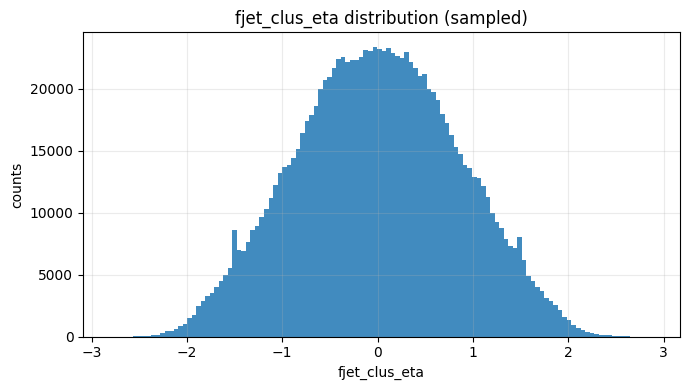


[fjet_clus_phi] sampled jets=20000 raw_shape=(2484117, 200) used_values=1,118,514
  min=-3.14159 max=3.14159 mean=-0.00485378 std=1.79945
  p  0.1=-3.13532
  p    1=-3.07734
  p    5=-2.81366
  p   25=-1.5407
  p   50=-0.0198145
  p   75=1.54692
  p   95=2.81546
  p   99=3.0737
  p 99.9=3.13407


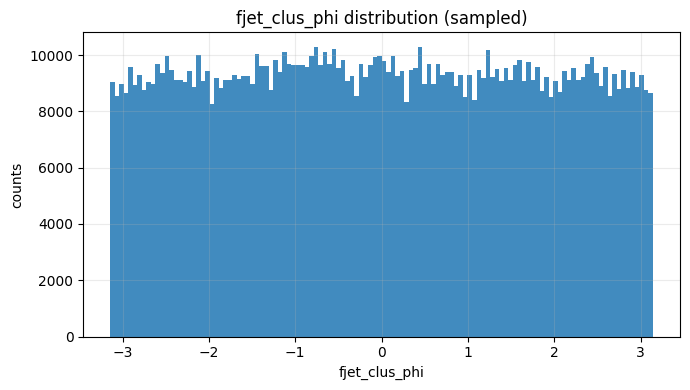


[fjet_clus_pt] sampled jets=20000 raw_shape=(2484117, 200) used_values=1,118,514
  min=100.064 max=3.3147e+06 mean=27060 std=91962.7
  p  0.1=245.017
  p    1=423.903
  p    5=668.102
  p   25=2143.66
  p   50=5132.68
  p   75=15123.2
  p   95=114770
  p   99=399332
  p 99.9=1.23478e+06


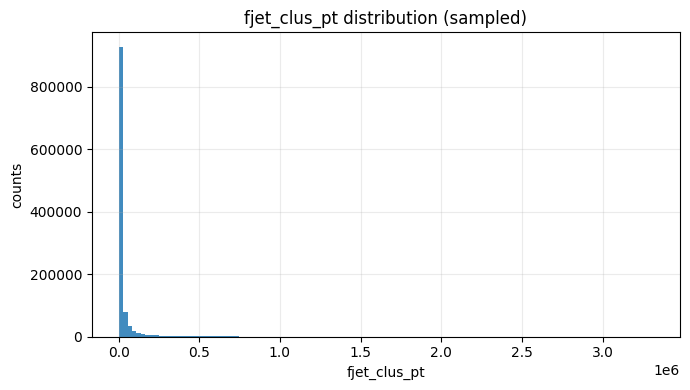


[fjet_clus_E] sampled jets=20000 raw_shape=(2484117, 200) used_values=1,118,514
  min=100.775 max=3.50094e+06 mean=35219.7 std=112974
  p  0.1=284.531
  p    1=524.322
  p    5=877.811
  p   25=2835.49
  p   50=6871.38
  p   75=20656.1
  p   95=151837
  p   99=513579
  p 99.9=1.4725e+06


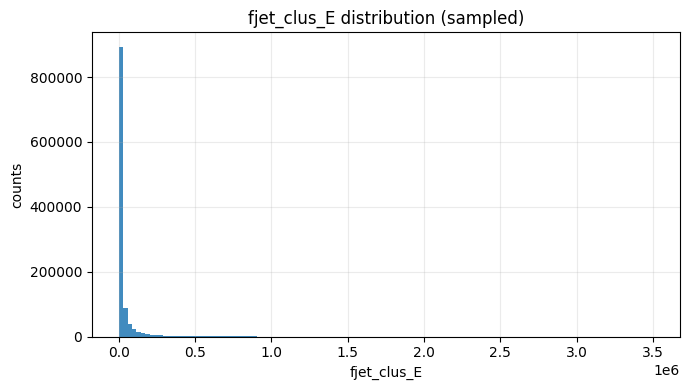

KeyError: "Unable to synchronously open object (object 'weight' doesn't exist)"

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def inspect_dist(
    key: str,
    *,
    n_jets: int = 20000,
    max_particles: int | None = None,
    seed: int = 42,
    bins: int = 120,
    logy: bool = False,
    mask_zero: bool = True,
    value_clip: tuple[float, float] | None = None,
    transform: str | None = None,  # None | 'log10' | 'ln'
    percentiles=(0.1, 1, 5, 25, 50, 75, 95, 99, 99.9),
):
    """Quick distribution inspection for any H5 dataset key.

    - Samples up to `n_jets` jets uniformly at random (to avoid loading full dataset).
    - If dataset is 2D ([N,S]), it samples jets and optionally truncates to `max_particles`.
    - Flattens values and (optionally) removes zeros.
    """
    ds = f[key]
    N = int(ds.shape[0])
    rng = np.random.default_rng(int(seed))
    n_sel = int(min(max(1, n_jets), N))
    # h5py requires integer-array indexing to be in increasing order
    idx = np.sort(rng.choice(N, size=n_sel, replace=False))

    vals = []
    step = 2048
    for start in range(0, n_sel, step):
        sel = idx[start : start + step]
        if ds.ndim == 1:
            x = ds[sel]
        elif ds.ndim == 2:
            S = int(ds.shape[1])
            s = int(min(S, max_particles)) if max_particles is not None else S
            x = ds[sel, :s]
        else:
            raise ValueError(f"Unsupported ndim={ds.ndim} for key={key}")
        vals.append(np.asarray(x))

    x = np.concatenate([v.reshape(-1) for v in vals], axis=0).astype(np.float64, copy=False)

    # Basic cleaning
    x = x[np.isfinite(x)]
    if mask_zero:
        x = x[x != 0]

    if value_clip is not None:
        lo, hi = float(value_clip[0]), float(value_clip[1])
        x = np.clip(x, lo, hi)

    if transform is not None:
        t = str(transform).lower()
        if t == 'log10':
            x = np.log10(np.clip(x, 1e-12, None))
        elif t in ('ln', 'log'):
            x = np.log(np.clip(x, 1e-12, None))
        else:
            raise ValueError(f"Unknown transform={transform!r}")

    print(f"\n[{key}] sampled jets={n_sel} raw_shape={tuple(ds.shape)} used_values={int(x.size):,}")
    if x.size == 0:
        print("No values after masking.")
        return

    print(f"  min={x.min():.6g} max={x.max():.6g} mean={x.mean():.6g} std={x.std():.6g}")
    ps = np.percentile(x, percentiles)
    for p, v in zip(percentiles, ps):
        print(f"  p{p:>5}={v:.6g}")

    plt.figure(figsize=(7, 4))
    plt.hist(x, bins=int(bins), alpha=0.85)
    plt.title(f"{key} distribution (sampled)")
    plt.xlabel(f"{key}" + (f" ({transform})" if transform else ""))
    plt.ylabel("counts")
    if logy:
        plt.yscale('log')
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


# Example (edit `key` to inspect any quantity):
inspect_dist('fjet_clus_eta', n_jets=20000, max_particles=200, mask_zero=True, bins=120)
inspect_dist('fjet_clus_phi', n_jets=20000, max_particles=200, mask_zero=True, bins=120)
inspect_dist('fjet_clus_pt', n_jets=20000, max_particles=200, mask_zero=True, bins=120)
inspect_dist('fjet_clus_E', n_jets=20000, max_particles=200, mask_zero=True, bins=120)

# e.g.
# inspect_dist('fjet_clus_pt', n_jets=20000, max_particles=200, mask_zero=True, bins=120, transform='log10', logy=True)
# inspect_dist('fjet_pt', n_jets=200000, mask_zero=True, bins=120)



[weights] sampled jets=20000 raw_shape=(2484117,) used_values=20,000
  min=0.154473 max=4.10554 mean=0.997698 std=0.599299
  p  0.1=0.154473
  p    1=0.154473
  p    5=0.163923
  p   25=0.74253
  p   50=1
  p   75=1
  p   95=2.3174
  p   99=2.9178
  p 99.9=4.06134


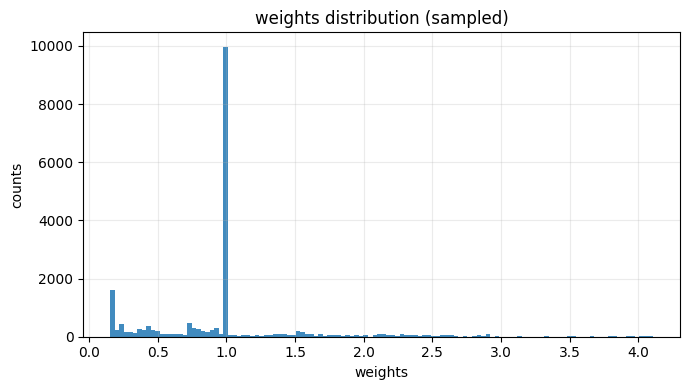

In [8]:
inspect_dist('weights', n_jets=20000, max_particles=200, mask_zero=True, bins=120)

In [8]:
import numpy as np

pt_ds = f['fjet_clus_pt']

n_jets = pt_ds.shape[0]
chunk_size = 10000
nonzero_counts = np.empty(n_jets, dtype=np.int32)

for start in range(0, n_jets, chunk_size):
    end = min(start + chunk_size, n_jets)
    pts = pt_ds[start:end]
    nonzero_counts[start:end] = (pts > 0).sum(axis=1)

print("Non-zero pt counts per jet:")
print(sum(nonzero_counts>60))


Non-zero pt counts per jet:
855239


In [3]:
a = 0.0
print(a>0.0)

False
